Usando o exemplo 499

In [30]:
%pip install pandas numpy seaborn xgboost imbalanced-learn
%pip install nltk
%pip install lime
%pip install shap

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [31]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
import shap

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.preprocessing import LabelEncoder
from lime import lime_text

from xgboost import XGBClassifier
from sklearn.feature_extraction.text import TfidfVectorizer

In [32]:
df = pd.read_csv('../FakeNewsNet.csv')

In [33]:
df.head()

,title,news_url,source_domain,tweet_num,real
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1


In [34]:
df.shape

(23196, 5)

<Axes: xlabel='real', ylabel='count'>

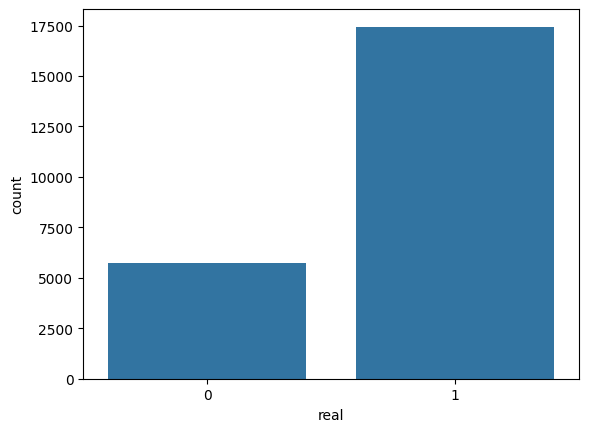

In [35]:
sns.countplot(x='real', data=df)

**Pré-Processamento**

In [36]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
import re

# Baixar pacotes necessários do NLTK
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("wordnet")
nltk.download('punkt_tab') # Download the 'punkt_tab' resource

[nltk_data] Downloading package stopwords to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to C:\Users\LUIRYS
[nltk_data]     SILVA\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [37]:
def preprocess_text(text):
    # Converter para minúsculas
    text = text.lower()

    # Remover caracteres especiais e números
    text = re.sub(r"[^a-zA-Z\s]", "", text)

    # Tokenização (dividir em palavras)
    tokens = word_tokenize(text)

    # Remover stopwords
    stop_words = set(stopwords.words("english"))
    tokens = [word for word in tokens if word not in stop_words]

    # Lematização (reduzir palavras à sua forma base)
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(word) for word in tokens]

    # Juntar as palavras processadas de volta em uma string
    return " ".join(tokens)

In [38]:
df["clean_text"] = df["title"].apply(preprocess_text)

In [39]:
df.head(5)

,title,news_url,source_domain,tweet_num,real,clean_text
0,Kandi Burruss Explodes Over Rape Accusation on...,http://toofab.com/2017/05/08/real-housewives-a...,toofab.com,42,1,kandi burruss explodes rape accusation real ho...
1,People's Choice Awards 2018: The best red carp...,https://www.today.com/style/see-people-s-choic...,www.today.com,0,1,people choice award best red carpet look
2,Sophia Bush Sends Sweet Birthday Message to 'O...,https://www.etonline.com/news/220806_sophia_bu...,www.etonline.com,63,1,sophia bush sends sweet birthday message one t...
3,Colombian singer Maluma sparks rumours of inap...,https://www.dailymail.co.uk/news/article-33655...,www.dailymail.co.uk,20,1,colombian singer maluma spark rumour inappropr...
4,Gossip Girl 10 Years Later: How Upper East Sid...,https://www.zerchoo.com/entertainment/gossip-g...,www.zerchoo.com,38,1,gossip girl year later upper east siders shock...


<Axes: xlabel='real', ylabel='count'>

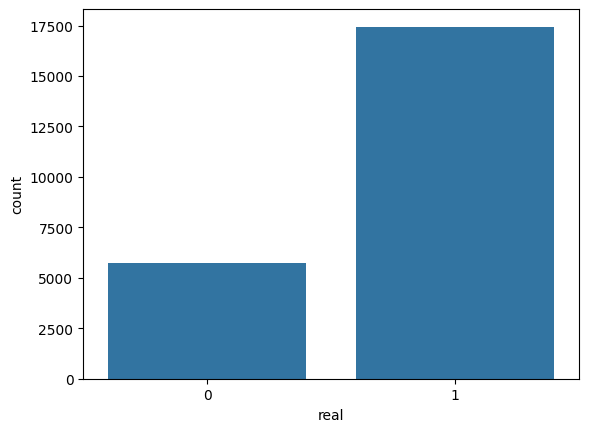

In [40]:
sns.countplot(x="real", data=df) # validando se mudou as classes

In [41]:
le = LabelEncoder()
df['label_encoded'] = le.fit_transform(df['real'])

In [42]:
X = df['clean_text']
y = df['label_encoded']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
#, stratify=y

In [43]:
tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words=None
)

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

**UNDERSAMPLING**

In [44]:
from imblearn.under_sampling import RandomUnderSampler

# Inicializar o RandomUnderSampler
rus = RandomUnderSampler(random_state=42) # random_state para reprodutibilidade

# Aplicar o undersampling aos dados de treino
X_train_resampled, y_train_resampled = rus.fit_resample(X_train_tfidf, y_train)

<Axes: xlabel='label_encoded', ylabel='count'>

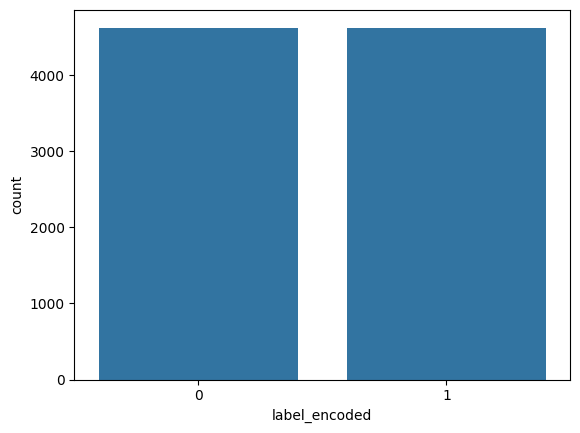

In [45]:
#verificar a nova distribuição de classes
sns.countplot(x=y_train_resampled)

**XGBoost**

In [46]:
model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    tree_method='hist',
    eval_metric='logloss',
    importance_type='gain',
    random_state=42,
    n_jobs=-1
)

In [47]:
# Validação estratificada (10%) sobre os dados já balanceados
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train_resampled, y_train_resampled,
    test_size=0.1,
    stratify=y_train_resampled,
    random_state=42
)

model.fit(
    X_tr, y_tr,
    eval_set=[(X_tr, y_tr), (X_val, y_val)],
    verbose=20
)

[0]	validation_0-logloss:0.68275	validation_1-logloss:0.68783
[20]	validation_0-logloss:0.59138	validation_1-logloss:0.64999
[40]	validation_0-logloss:0.55503	validation_1-logloss:0.63908
[60]	validation_0-logloss:0.53116	validation_1-logloss:0.63276
[80]	validation_0-logloss:0.51262	validation_1-logloss:0.62749
[100]	validation_0-logloss:0.49783	validation_1-logloss:0.62408
[120]	validation_0-logloss:0.48496	validation_1-logloss:0.62132
[140]	validation_0-logloss:0.47364	validation_1-logloss:0.61987
[160]	validation_0-logloss:0.46364	validation_1-logloss:0.61839
[180]	validation_0-logloss:0.45422	validation_1-logloss:0.61717
[199]	validation_0-logloss:0.44637	validation_1-logloss:0.61661


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


**Métricas**

In [48]:
from sklearn.metrics import classification_report

# Fazer previsões no conjunto de teste
y_pred = model.predict_proba(X_test_tfidf)      # probabilidades
y_pred_classes = model.predict(X_test_tfidf)    # classes (já em 0/1)

# Gerar o relatório de classificação
print(classification_report(y_test, y_pred_classes))

              precision    recall  f1-score   support

           0       0.55      0.63      0.59      1131
           1       0.88      0.83      0.85      3509

    accuracy                           0.78      4640
   macro avg       0.71      0.73      0.72      4640
weighted avg       0.80      0.78      0.79      4640



In [49]:
#acuracia,precisão, recall e f1-score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
def calculate_metrics(y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average='weighted')
    recall = recall_score(y_true, y_pred, average='weighted')
    f1 = f1_score(y_true, y_pred, average='weighted')
    
    return accuracy, precision, recall, f1
# Calcular as métricas
accuracy, precision, recall, f1 = calculate_metrics(y_test, y_pred_classes)
print(f"Acurácia: {accuracy:.4f}")
print(f"Precisão: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1:.4f}")

Acurácia: 0.7819
Precisão: 0.7951
Recall: 0.7819
F1-Score: 0.7872


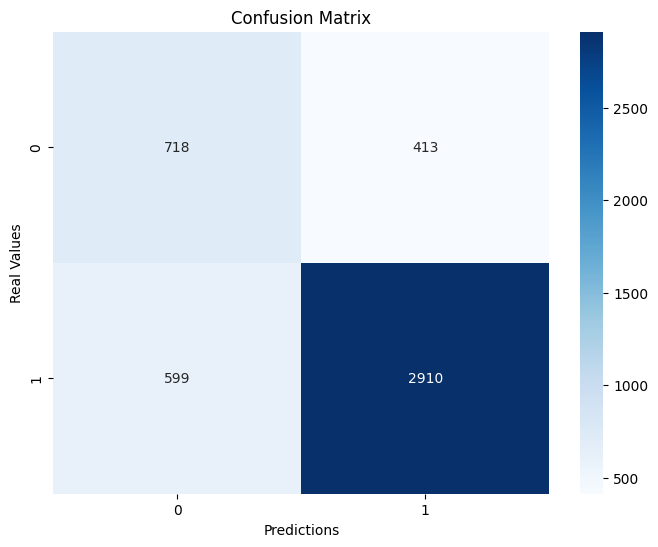

In [50]:
# Calcular a matriz de confusão
conf_matrix = confusion_matrix(y_test, y_pred_classes)

# Criar o heatmap da matriz de confusão
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predictions")
plt.ylabel("Real Values")
plt.title("Confusion Matrix")
plt.show()

**LIME**

In [51]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=le.classes_)

def predict_proba(texts):
    X = tfidf.transform(texts)          # mantém esparso
    return model.predict_proba(X)

idx = int(input(f"Digite o número da linha (0 a {len(X_test)-1}): "))
sample_text = X_test.iloc[idx]
sample_label = y_test.iloc[idx]

sample_tfidf = tfidf.transform([sample_text])   # sem .toarray()

pred_probs = model.predict_proba(sample_tfidf)
pred_class_idx = pred_probs.argmax(axis=1)[0]
pred_class_name = le.classes_[pred_class_idx]

print(f"Número da linha no X_test: {idx}")
print(f"Original text:\n{sample_text}")
print(f"Classe real: {le.classes_[sample_label]}")
print(f"Classe predita: {pred_class_name}")

explanation = explainer.explain_instance(
    sample_text,
    predict_proba,
    num_features=10
)

print(explanation.as_list())

Número da linha no X_test: 499
Original text:
style tip dressing like princess eleanor royal
Classe real: 1
Classe predita: 1
[(np.str_('like'), 0.10260461625401021), (np.str_('eleanor'), 0.005930058532172184), (np.str_('style'), 0.005829608368829659), (np.str_('princess'), 0.005822920602549547), (np.str_('tip'), 0.005638770142935663), (np.str_('dressing'), -0.0016136853022385776), (np.str_('royal'), 1.3474185154268121e-05)]


In [52]:
# Obtém as palavras mais importantes e seus pesos
lime_features = explanation.as_list()

# Exibe cada palavra com seu impacto na predição
print("Palavras mais importantes e seus pesos:")
for word, weight in lime_features:
    print(f"{word}: {weight:.4f}")

Palavras mais importantes e seus pesos:
like: 0.1026
eleanor: 0.0059
style: 0.0058
princess: 0.0058
tip: 0.0056
dressing: -0.0016
royal: 0.0000


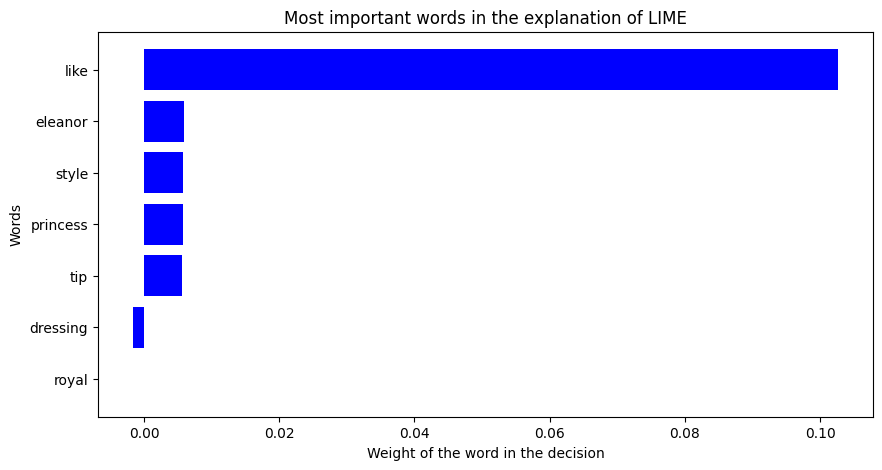

In [53]:
# Separar palavras e pesos
words, weights = zip(*lime_features)

# Criar gráfico de barras
plt.figure(figsize=(10, 5))
plt.barh(words, weights, color="blue")
plt.xlabel("Weight of the word in the decision")
plt.ylabel("Words")
plt.title("Most important words in the explanation of LIME")
plt.gca().invert_yaxis()  # Inverter para mostrar a palavra mais importante no topo
plt.show()

In [54]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Imprimir as palavras e pesos
for word, weight in words_weights:
    print(f"{word}: {weight}")

like: 0.10260461625401021
eleanor: 0.005930058532172184
style: 0.005829608368829659
princess: 0.005822920602549547
tip: 0.005638770142935663
dressing: -0.0016136853022385776
royal: 1.3474185154268121e-05


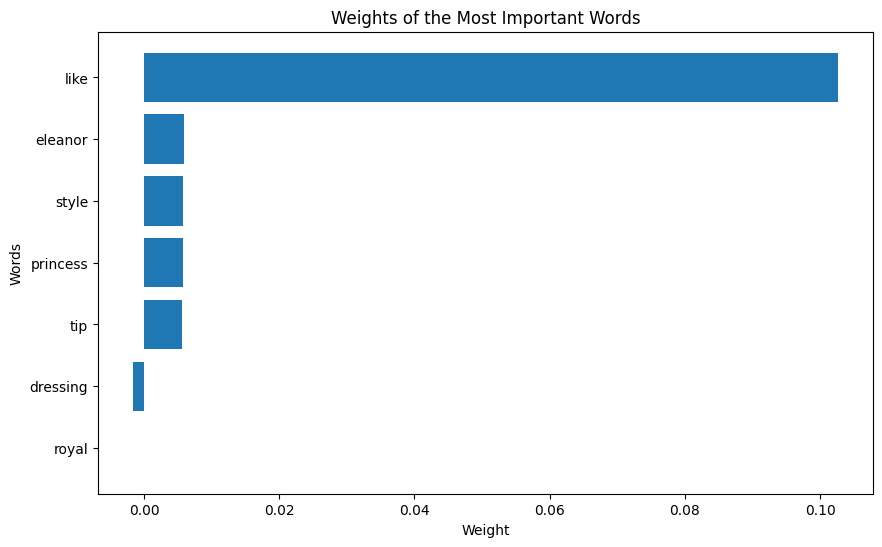

In [55]:
# Obter as palavras mais importantes e seus pesos no geral
words_weights = explanation.as_list()

# Separar palavras e pesos em listas separadas
words = [word for word, weight in words_weights]
weights = [weight for word, weight in words_weights]

# Criar o gráfico de barras horizontais
plt.figure(figsize=(10, 6))  # Ajustar o tamanho da figura, se necessário
plt.barh(words, weights)
plt.xlabel("Weight")
plt.ylabel("Words")
plt.title("Weights of the Most Important Words")
plt.gca().invert_yaxis()  # Inverter o eixo y para que as palavras mais importantes estejam no topo
plt.show()

**Attention Viz**

Texto usado na explicação:
style tip dressing like princess eleanor royal

Classe prevista: 1
Probabilidades: [0.2298708 0.7701292]
Importance: (5000,)
Número de palavras: 6
    Feature     TFIDF    Weight  Contribution
4     style  0.353596  0.002634      0.000931
1      like  0.347429  0.002529      0.000879
2  princess  0.379582  0.000906      0.000344
3     royal  0.321195  0.000792      0.000254
0   eleanor  0.553429  0.000000      0.000000
5       tip  0.448030  0.000000      0.000000


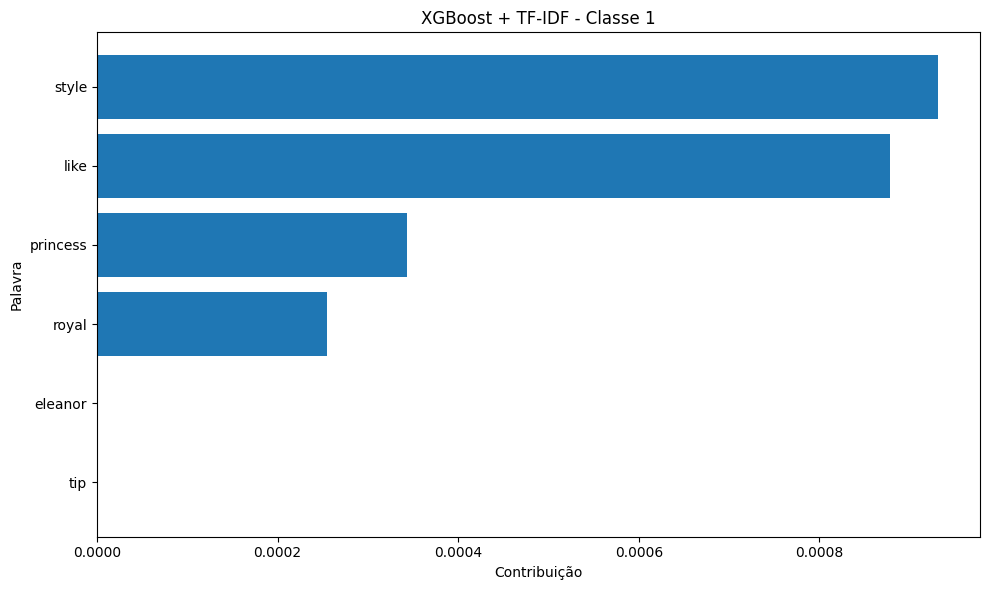

In [56]:
lime_idx = 499

sample_text = X_test.iloc[lime_idx]
print("Texto usado na explicação:")
print(sample_text)

# ETAPA 1: PREVISÃO
sample_tfidf = X_test_tfidf[lime_idx:lime_idx+1]
prediction = model.predict_proba(sample_tfidf)
predicted_class_index = np.argmax(prediction[0])

print(f"\nClasse prevista: {predicted_class_index}")
print("Probabilidades:", prediction[0])

# ETAPA 2: IMPORTÂNCIA GLOBAL DAS FEATURES (ganho médio dos splits)
feature_names = tfidf.get_feature_names_out()
global_importance = model.feature_importances_

print("Importance:", global_importance.shape)

# ETAPA 3: PALAVRAS PRESENTES NO TEXTO
tfidf_vector = sample_tfidf.toarray().flatten()
indices = np.where(tfidf_vector > 0)[0]
print("Número de palavras:", len(indices))

palavras = feature_names[indices]
pesos = global_importance[indices]
contribuicao = tfidf_vector[indices] * pesos

importancias = pd.DataFrame({
    "Feature": palavras,
    "TFIDF": tfidf_vector[indices],
    "Weight": pesos,
    "Contribution": contribuicao
}).sort_values(by="Contribution", ascending=False)

print(importancias.head(20))

# ETAPA 4: VISUALIZAÇÃO
top = importancias.head(20)

plt.figure(figsize=(10, 6))
plt.barh(top["Feature"], top["Contribution"])
plt.xlabel("Contribuição")
plt.ylabel("Palavra")
plt.title(f"XGBoost + TF-IDF - Classe {predicted_class_index}")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Shapley

Classe prevista: 1
Palavras: ['like' 'style' 'princess' 'royal' 'tip' 'eleanor']
TF-IDF: [0.34742854 0.35359552 0.37958216 0.32119538 0.44803029 0.55342876]
SHAP: [ 0.49188933  0.11072969  0.00141732 -0.00117533  0.          0.        ]


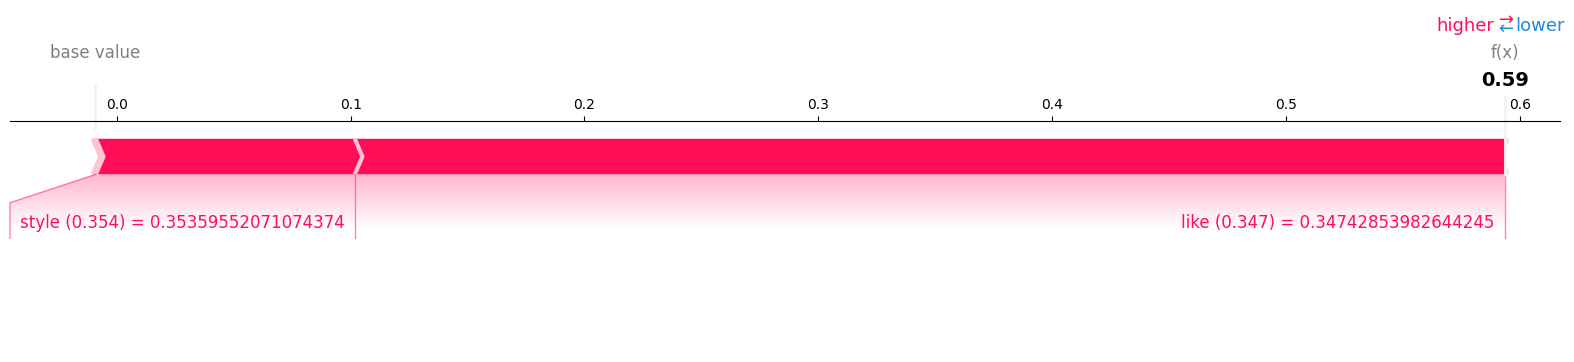

In [57]:
lime_idx = 499

X_instance = X_test_tfidf[lime_idx:lime_idx+1]   # mantém esparso

# Classe prevista
pred_probs = model.predict_proba(X_instance)
pred_class_idx = np.argmax(pred_probs, axis=1)[0]
print("Classe prevista:", pred_class_idx)

# TreeExplainer
explainer = shap.TreeExplainer(model)
shap_values = np.array(explainer.shap_values(X_instance)).reshape(-1)

expected_value = explainer.expected_value
if isinstance(expected_value, (list, np.ndarray)):
    expected_value = float(np.array(expected_value).reshape(-1)[0])

# O SHAP do XGBoost binário explica a classe 1 (em log-odds).
# Se a classe prevista for 0, inverte o sinal para explicar a classe prevista.
if pred_class_idx == 0:
    shap_values = -shap_values
    expected_value = -expected_value

# Palavras presentes no documento
feature_names = np.array(tfidf.get_feature_names_out())
tfidf_vector = X_instance.toarray().reshape(-1)
indices = np.where(tfidf_vector > 0)[0]

words = feature_names[indices]
values = shap_values[indices]
tfidf_values = tfidf_vector[indices]

# Ordenar por impacto absoluto
top_k = 15
order = np.argsort(np.abs(values))[::-1][:top_k]

words = words[order]
values = values[order]
tfidf_values = tfidf_values[order]

formatted_labels = [f"{w} ({t:.3f})" for w, t in zip(words, tfidf_values)]

print("Palavras:", words)
print("TF-IDF:", tfidf_values)
print("SHAP:", values)

shap.force_plot(
    base_value=expected_value,
    shap_values=values,
    features=tfidf_values,
    feature_names=formatted_labels,
    matplotlib=True
)